> **Статус миграции:** это пока действующий объединённый источник, а не окончательно разделённый ноутбук.
> 
> Предусмотренное разделение: `70.01`, `70.03`, `70.04` и `70.05`. Полная копия происхождения: `archive/legacy/70.90_Объединённый_прототип_РЕО32.ipynb`. Новые каркасы не считаются реализованными до переноса и сравнения вычислений.


In [ ]:
%matplotlib inline
!pip install "vegafusion[embed]>=1.5.0"
!pip install "vl-convert-python>=1.6.0"
!pip install SALib


In [ ]:
# @title Информация о сигналах и исследовании
comments = {
    5: "Горизонтальный",
    7: "Мягкие ткани",
    9: "Вертикальный",
    13: "Лёгкие",
    16: "ЭКГ",
    32: "Трансторакальный",
    'default': "Нет описания"
}

def extract_number(signal_name):
    match = re.search(r'\((\d+)\)', signal_name)
    return int(match.group(1)) if match else None

def get_signal_with_comment(name):
    number = extract_number(name)
    return f"{name} — {comments.get(number, comments['default'])}"


fat_a=70/1000
fat_b=35/1000

heart_a=90/1000
heart_b=45/1000

Нормостеник


5 отв. - поперек сердца (180 х 90)

7 отв. - первый слой (140 х 70 )

9 отв. - вдоль сердца (180 х 90)

13 отв. - правое легкое (6 межреберье, 5 см от грудины и позвоночника, 5 см между потенциальным и токовым)


    
Сердце 180х90  
a=90, b=45




Мягкие 140х70

a=70, b=35

Построение всех графиков из txt файла из РЕО.

Название графика- folder/folder/***.txt

графики сортируются по возрастанию номера канала.

Галочками по умолчанию отключен вывод базового импеданса и по умолчанию включена инверсия ЭКГ.

После выбора каналов необходимо обновить график.

В справочных данных выводится среднее значение базового импеданса.


Другой способ вывода графика (через Altair)


Показался удобне, поскольку есть зум и прям в самом графике можно выбирать необходимые каналы, без надобности кликать по галочкам и обновлять.


In [ ]:
# @title Вывод графиков из выбранного файла (одного)
import pandas as pd
import numpy as np
import os, json
from pathlib import Path
import altair as alt
from ipywidgets import widgets
from IPython.display import display, clear_output
import re

# altair config
alt.data_transformers.enable("vegafusion")

#Частота дискретизации
fs = 500

# Слайдер выбора диапазона времени
time_slider = widgets.FloatRangeSlider(
    value=[4, 6],
    min=0,
    max=10,  # будет обновлено после загрузки файла
    step=0.1,
    description='Время (с):',
    continuous_update=False,
    layout=widgets.Layout(width='100%')
)

config_path = Path(os.environ["KALMYKOV_EXP01_CONFIG"]).expanduser().resolve()
config = json.loads(config_path.read_text(encoding="utf-8"))
folder_path = str(Path(config["data_root"]).expanduser().resolve())

# === Поиск всех .txt файлов внутри, игнорируя "checkpoint" ===
def find_txt_files(folder):
    txt_files = []
    for root, _, files in os.walk(folder):
        if "checkpoint" in root:
            continue  # Пропустить папки, содержащие "checkpoint"
        for file in files:
            if file.endswith('.txt') and "checkpoint" not in file:
                full_path = os.path.join(root, file)
                txt_files.append(full_path)
    return txt_files


txt_files = find_txt_files(folder_path)

# === Виджет выбора файла ===
file_dropdown = widgets.Dropdown(
    options=txt_files,
    description='Файл:',
    layout=widgets.Layout(width='100%')
)



# Глобальные переменные (будут меняться при смене файла)
checkboxes = []
hidden_B_columns = []
df = pd.DataFrame()
time = []

# Вспомогательные функции

def generate_title_text(path):
    base = os.path.basename(os.path.splitext(path)[0])
    parent = os.path.basename(os.path.dirname(path))
    grandparent = os.path.basename(os.path.dirname(os.path.dirname(path)))
    return f"({grandparent}_{parent}_{base})"

def extract_number(signal_name):
    match = re.search(r'\((\d+)\)', signal_name)
    return int(match.group(1)) if match else float('inf')

# Загрузка файла и обновление чекбоксов
def load_file(file_path):
    global df, time, checkboxes, hidden_B_columns
    df = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')
    df = df.dropna(axis=1, how='all')
    time = np.arange(len(df)) / fs

    checkboxes = []
    hidden_B_columns = []

    for col in df.columns:
        if col.startswith('Б'):
            checkboxes.append(widgets.Checkbox(value=False, description=col))
            hidden_B_columns.append(col)
        else:
            checkboxes.append(widgets.Checkbox(value=True, description=col))

    duration = len(df) / fs
    time_slider.min = 0
    time_slider.max = round(duration, 1)
    time_slider.value = [4, 6] if duration > 6 else [0, round(duration, 1)]

    return widgets.VBox(checkboxes)

# Инверсия ЭКГ
invert_ecg_checkbox = widgets.Checkbox(value=True, description='Инвертировать ЭКГ')

# Преобразование в long-form
def get_long_df():
    long_data = []

    for cb in checkboxes:
        if cb.value:
            col = cb.description
            signal = df[col].copy()
            if invert_ecg_checkbox.value and col.startswith('ЭКГ'):
                signal = -signal
            if col.startswith('ЭКГ'):
                signal = signal / 10 - 200

            long_data.append(pd.DataFrame({
                'Time': time,
                'Value': signal,
                'Signal': col,
                'SignalFull': get_signal_with_comment(col)
            }))
    start_time, end_time = time_slider.value
    if long_data:
        combined_df = pd.concat(long_data, ignore_index=True)
        return combined_df[(combined_df['Time'] >= start_time) & (combined_df['Time'] <= end_time)]

    else:
        return pd.DataFrame(columns=['Time', 'Value', 'Signal'])

# Построение графика
def show_altair_plot(_):
    long_df = get_long_df()
    if long_df.empty:
        print("Нет выбранных сигналов.")
        return

    selection = alt.selection_point(fields=['SignalFull'], bind='legend')
    sorted_signals = sorted(long_df['SignalFull'].unique(), key=extract_number)

    chart = alt.Chart(long_df).mark_line().encode(
        x=alt.X('Time', title='Время (сек)'),
        y=alt.Y('Value', title='Значение'),
        color=alt.Color('SignalFull:N', sort=sorted_signals, legend=alt.Legend(title='Сигналы')),
        opacity=alt.condition(selection, alt.value(1), alt.value(0.1))
    ).add_params(
        selection
        ).properties(
        width=1200,
        height=600,
        title=generate_title_text(file_dropdown.value)
    ).interactive()

    # Комментарии


    clear_output(wait=True)
    display(file_dropdown, checkbox_box, invert_ecg_checkbox, time_slider, altair_button)

    display(chart)

# Обработка выбора файла
def on_file_change(change):
    global checkbox_box
    checkbox_box = load_file(change['new'])
    clear_output(wait=True)
    display(file_dropdown, checkbox_box, invert_ecg_checkbox, time_slider, altair_button)


file_dropdown.observe(on_file_change, names='value')

# Кнопка для построения графика
altair_button = widgets.Button(description='Показать график', button_style='success')
altair_button.on_click(show_altair_plot)

# Начальная загрузка
checkbox_box = load_file(file_dropdown.value)
display(file_dropdown, checkbox_box, invert_ecg_checkbox, time_slider, altair_button)



!!!


---


Выбранные выше параметры для одного графика подтягиваются сюда для генерации всех графиков


---



In [ ]:
#@title выбор канала для учёта deltaZ
# Глобальная переменная для хранения половины амплитуды ПРКГ
half_amplitude_Z = None

#Интерфейс для выбора ПРКГ и расчёта половины амплитуды
def show_prkg_amplitude_interface():
    global half_amplitude_Z

    if df.empty:
        print("Сначала выберите и загрузите файл.")
        return

    # Найти все сигналы, начинающиеся с 'ПРКГ'
    prkg_columns = [col for col in df.columns if col.startswith('ПРКГ')]

    if not prkg_columns:
        print("В выбранном файле нет сигналов, начинающихся с 'ПРКГ'.")
        return

    # Виджет: выбор одного ПРКГ-сигнала
    prkg_radio = widgets.RadioButtons(
        options=prkg_columns,
        description='Канал:',
        layout=widgets.Layout(width='100%')
    )

    # Слайдер диапазона времени
    duration = len(df) / fs
    prkg_slider = widgets.FloatRangeSlider(
        value=[4, 5] if duration > 4 else [0, round(duration, 1)],
        min=0,
        max=round(duration, 1),
        step=0.1,
        description='Диапазон:',
        continuous_update=False,
        layout=widgets.Layout(width='100%')
    )

    # Кнопка запуска расчёта
    amp_button = widgets.Button(description='Сохранить амплитуду', button_style='info')

    # Обработчик кнопки
    def on_amp_button_click(_):
        global half_amplitude_Z

        selected_col = prkg_radio.value
        start_time, end_time = prkg_slider.value
        start_idx = int(start_time * fs)
        end_idx = int(end_time * fs)

        signal = df[selected_col].iloc[start_idx:end_idx]
        amplitude = signal.max() - signal.min()
        half_amplitude_Z = amplitude / 2 / 1000

        clear_output(wait=True)
        display(prkg_radio, prkg_slider, amp_button)
        print(f"Выбран канал: {selected_col}")
        print(f"half_amplitude_Z = {half_amplitude_Z} Ом")

    amp_button.on_click(on_amp_button_click)

    # Отобразить интерфейс
    display(prkg_radio, prkg_slider, amp_button)


show_prkg_amplitude_interface()



In [ ]:
# @title Вывод медианных значений для всех сигналов из исследования
import seaborn as sns
import matplotlib.pyplot as plt

# Словарь для хранения медиан
median_values = {}

for file_path in txt_files:
    try:
        df_local = pd.read_csv(file_path, delimiter='\t', encoding='utf-8')
        df_local = df_local.dropna(axis=1, how='all')

        # Скрытые каналы
        hidden_B_columns = [col for col in df_local.columns if col.startswith('Б')]
        if not hidden_B_columns:
            continue

        # Медианы по скрытым каналам
        medians = {col: df_local[col].median() for col in hidden_B_columns if col in df_local.columns}
        if medians:
            median_values[generate_title_text(file_path)] = medians

    except Exception as e:
        print(f"❌ Ошибка при обработке {file_path}: {e}")

# Преобразование в DataFrame
median_df = pd.DataFrame(median_values).T  # строки — файлы, столбцы — 'Б' каналы

# Отрисовка тепловой карты
plt.figure(figsize=(12, max(3, len(median_df) * 0.5)))
sns.heatmap(median_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Медианное значение'})
plt.title("Медианные значения базового импеданса")
plt.xlabel("Каналы")
plt.ylabel("Файлы")
plt.tight_layout()
plt.show()


исходя из адекватности решения, в качестве значения импеданса для расчета сопротивления мягких тканей возьмём медианное значение базовго импеданса из эксперимента по время задержки дыхания на выдохе.


In [ ]:
# @title Выбор сигнала для определения базового импеданса мягких тканей
# Выводим доступные файлы и каналы
print("Доступные файлы:")
for i, file_name in enumerate(median_df.index):
    print(f"{i}: {file_name}")

file_index = int(input("Введите номер файла: "))
selected_file = median_df.index[file_index]

print("\nДоступные каналы:")
for i, channel in enumerate(median_df.columns):
    print(f"{i}: {channel}")

channel_index = int(input("Введите номер канала: "))
selected_channel = median_df.columns[channel_index]

# Получение медианного значения
z = median_df.loc[selected_file, selected_channel]

print(f"\nВыбрано: файл = '{selected_file}', канал = '{selected_channel}'")
print(f"Медианное значение (z) = {z}")


Расчёты ==ДЛЯ ОДНОЙ ЭЛЕКТРОДНОЙ СБОРКИ==

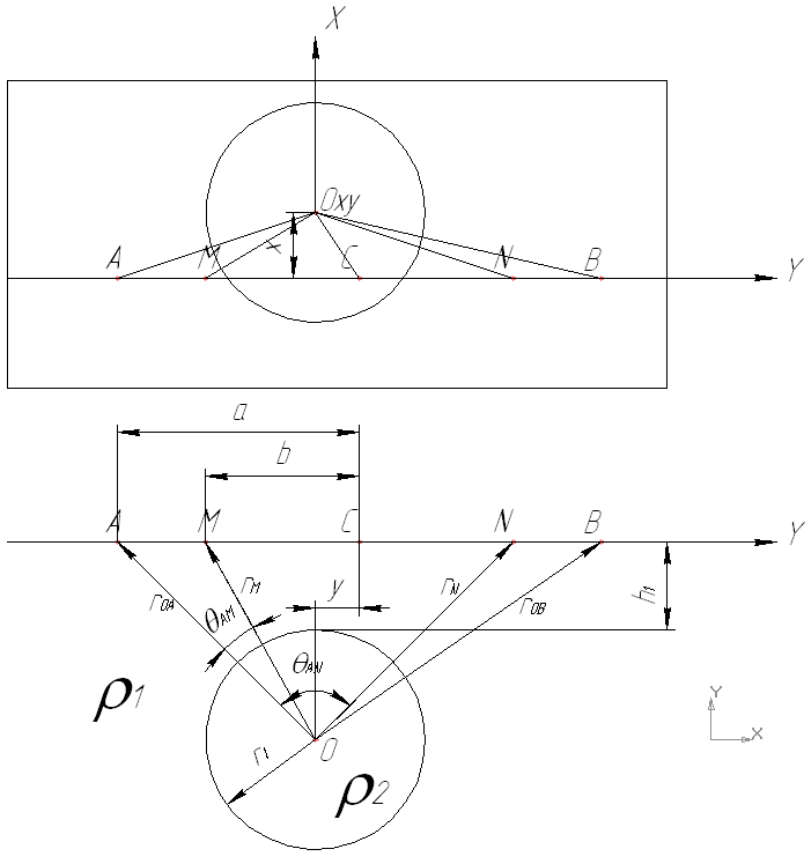

## Уравнения и переменные: происхождение и значения

Сводный справочник ко всей модели одной сборки. Полный вывод «с нуля» — в [01_Математическая_модель_импеданса.md](70.02_Прямая_модель_эквивалентной_сферы_РЕО32.md); перекрёстная (двухсборочная) локализация и идентифицируемость — в [15_Кросс_локализация_и_траектории_сферы.md](70.06_Совместная_модель_каналов_5_и_9.md).

### Уравнения

| Формула | Смысл | Откуда (вывод) | В коде |
|---|---|---|---|
| $Z_{\text{одн}}=\dfrac{2\rho_1 b}{\pi(a^2-b^2)}$ | импеданс однородного полупространства без сферы | тетраполярная комбинация потенциалов точечного источника с зеркальным изображением от изолирующей поверхности (doc 01 §2.1–2.2, ф. 4) | `one_layer_model`; первое слагаемое `Zbase`, `optimized_Zbase_scalar` |
| $A_n=\dfrac{n(\rho_2-\rho_1)}{(n+1)\rho_2+n\rho_1}$ | мультипольный коэффициент сферы, порядок $n$ | граничные условия (непрерывность потенциала и нормального тока) на поверхности шара $r=R$ (doc 01 §3.2) | `coefs = n*(rho2-rho1)/((n+1)*rho2+n*rho1)` |
| $dZ_{pq}=\dfrac{\rho_1}{\pi r_0}\sum\limits_{n=1}^{N}\left(\dfrac{R}{r_{\text{in}}}\right)^{n+1}\!\left(\dfrac{R}{r_0}\right)^{n}\!A_n P_n(\cos\theta)$ | возмущение импеданса от сферы для одной пары источник–приёмник | разложение возмущённого потенциала по полиномам Лежандра + учёт изолирующей поверхности тела (doc 01 §3.3–3.4, ф. 7) | `dZ_component` / `compute_component` / `vectorized_component` |
| $dZ=dZ_{AM}-dZ_{AN}+dZ_{BN}-dZ_{BM}$ | вклад сферы для тетраполярной сборки | та же знаковая комбинация 4 пар, что и в $Z_{\text{одн}}$ (doc 01 §3.5, ф. 10) | `dZ_total`; `dz_am - dz_an + dz_bn - dz_bm` |
| $\boxed{Z=Z_{\text{одн}}+dZ}$ | полный импеданс сборки (прямая задача) | сумма (4)+(10) (doc 01 §3.5, ф. 11) | `Zbase`, `optimized_Zbase_scalar` |
| $\rho_1=\dfrac{Z\,\pi(a^2-b^2)}{2b}$ | оценка $\rho_1$ по базовому импедансу | обращение однослойной модели (4) относительно $\rho_1$ (doc 01 §2.3, ф. 5) | `return_rho1` |
| $F(R)=Z(R)-Z^{*}=0$ | обратная задача: радиус по импедансу | монотонность $Z(R)$ на физиологич. интервале ⇒ единственный корень (doc 01 §5.1, ф. 16) | `find_r1_surface` через `scipy.optimize.brentq` |
| $Z_1=Z_{\text{баз}}+\tfrac12 A_Z,\ Z_2=Z_{\text{баз}}-\tfrac12 A_Z$ | импеданс в систолу / диастолу | $\rho_2<\rho_1$: больший радиус (диастола) ⇒ меньший $Z$ (doc 01 §5.2) | ячейка «Из графика пульсового импеданса…» |
| $Z_{\text{2сл}}$ (ряд изображений с $k=\tfrac{\rho_2-\rho_1}{\rho_2+\rho_1}$) | плоская двуслойная модель (проверочная) | метод изображений для слоя над полупространством (doc 01 §3.7, ф. 13) | `two_layer_model` (в расчётах не используется) |

Углы $\theta_{pq}$ между направлениями на источник и приёмник — по теореме косинусов через евклидовы расстояния (doc 01 §3.3, ф. 9): `cos_theta_* = (RA**2 + RM**2 - |AM|**2)/(2*RA*RM)` и аналоги.

### Переменные и параметры

| Символ | В коде | Смысл | Откуда взято | Значение | Ед. |
|---|---|---|---|---|---|
| $a$ (сердце) | `heart_a`, `a0` | полурасстояние между **токовыми** электродами | монтаж над сердцем $180\times90$ мм (каналы 5, 9) | $0{,}090$ | м |
| $b$ (сердце) | `heart_b`, `b10`, `br0` | полурасстояние между **потенциальными** электродами | тот же монтаж $180\times90$ | $0{,}045$ | м |
| $a$ (мягкие тк.) | `fat_a` | полурасстояние токовых, канал мягких тканей | монтаж $140\times70$ мм (канал 7, «первый слой») | $0{,}070$ | м |
| $b$ (мягкие тк.) | `fat_b` | полурасстояние потенциальных, мягкие ткани | монтаж $140\times70$ | $0{,}035$ | м |
| $Z_{\text{баз}}$ | `z` | базовый импеданс канала мягких тканей | **эксперимент**: медиана БПРКГ(7), файл «лёжа/выдох» (задержка на выдохе) | $42{,}043$ | Ом |
| $\rho_1$ | `rho1` | уд. сопротивление мягких тканей | **вычислено** по (5) из `z` с **fat-геометрией** (70/35) | $6{,}9343$ | Ом·м |
| $\rho_2$ | `rho2` | уд. сопротивление крови/сердца | **литература/эксперимент**: отчёт РФФИ | $1{,}35$ | Ом·м |
| $h$ | `h1` | глубина залегания — до **верхней точки** сферы | анатомическое допущение (в идеале из МРТ/КТ) | $0{,}025$ | м |
| $R$ | `r1` | номинальный радиус эквивалентной сферы в середине пульсового диапазона | анатомическое начальное приближение (МРТ) | $0{,}040$ | м |
| $R+h$ | — | глубина **центра** сферы (производная величина) | $r1+h1$ | $0{,}065$ | м |
| $\Delta r$ | `delta_r` | полный расчётный размах радиуса между систолой и диастолой | обращение прямой модели по измеренному $A_Z/2$ | вычисляется | м |
| $x,\ y$ | `x0`, `y0` | смещение центра сферы в плоскости кожи | допущение «сфера центрирована» | $0;\ 0$ | м |
| $N$ | `N` | число членов ряда Лежандра | сходимость проверена (см. ячейку-обоснование выше) | $20$ | — |
| $A_Z/2$ | `half_amplitude_Z` | половина размаха пульсовой кривой ПРКГ | **эксперимент** (ячейка «выбор канала для учёта deltaZ»); зависит от выбора канала/окна | $\approx0{,}051$ (пример: ПРКГ(5), лёжа/вдох) | Ом |
| $f_s$ | `fs` | частота дискретизации сигнала | установка измерения | $500$ | Гц |
| $P_n$ | `eval_legendre(n, ·)` | полином Лежандра степени $n$ | спец. функция | — | — |

### Замечания о точности и происхождении (важно)

1. **$\rho_1$ измеряется на мягких тканях, применяется к сердцу.** `rho1` вычисляется из канала мягких тканей с геометрией $140\times70$ (`fat_a,fat_b`), а в расчётах сердца используется геометрия $180\times90$ (`heart_a,heart_b`). Это намеренно (doc 01 §2.3): $\rho_1$ — свойство среды, а не сборки.
2. **$h$ — до верха сферы, не до центра.** В расстояния (ф. 2 doc 01) входит $R+h$, т.е. центр сферы лежит на глубине $R+h=65$ мм, а `h1`$=25$ мм — только зазор кожа→верх сферы. Частый источник путаницы.
3. **$\Delta r$ не задаётся вручную.** Систолический и диастолический радиусы вычисляются как корни $Z(R)-Z^*=0$ по измеренной полуамплитуде `half_amplitude_Z`; это устраняет прежнее несогласованное тестовое значение 10 мм.
4. **$x=y=0$ ⇒ латеральная чувствительность равна нулю.** В центрированной конфигурации $\partial Z/\partial x=\partial Z/\partial y=0$ (симметрийный ноль); это делает латеральное смещение ненаблюдаемым и разбирается в [15_Кросс_локализация_и_траектории_сферы.md](70.06_Совместная_модель_каналов_5_и_9.md).
5. **$\rho_2$ — внешний параметр.** Взят из отчёта РФФИ как типичное сопротивление крови/миокарда; не восстанавливается в этой модели, а задаётся.


Электрический импеданс, измеряемый между точками M и N (между потенциальными электродами) определяется соотношением (3)

$$ Z = Z_{\text{oДH}} + Z_{\text{cфер}} \tag{3} $$


$$Z = \frac{2 \rho_1 b}{\pi (a^2 - b^2)} + dZ(\rho_1, \rho_2, a, b, R, h, x, y) \tag{4} $$

In [ ]:
# @title Расчёт импеданса для однослойной модели без сферического включения (кровенаполнение мягких тканей)
def one_layer_model(rho1, a, b):
    return (rho1 * 2 * b) / (np.pi * (a ** 2 - b ** 2))


In [ ]:
# @title Ранняя реализация сферической модели — удалена

# Здесь находились zep / sub_z / sphere_influence / sphere_model: та же формула,
# что и в канонических ячейках 34-35, но эти функции нигде не вызывались и вызов
# был бы невозможен — они обращались к scipy.special.legendre(n), который в этом
# ноутбуке не импортируется (импортируется только eval_legendre), что дало бы
# NameError. Кроме того, в них оставалось N=101: именно построение полиномов
# через legendre(n) при n≈90-100 вызывало переполнение float64.
#
# Каноническая реализация:
#   dZ_component / dZ_total / Zbase   — ячейка 34 (скалярная),
#   optimized_Zbase_scalar            — ячейка 35 (векторизованная).
# Однослойная формула без включения — one_layer_model, ячейка 20.

В модели сокращение сердца описывается изменением радиуса эквивалентной сферы. Для обеспечения возможности независимого изменения радиуса эквивалентной сферы в области каждой электродной системы, для каждого из 2-х каналов рассматривается не только своя локальная эквивалентная сфера, но и свои геометрические параметры математической модели.
$$
Z_i = \frac{2 \cdot \rho_{1i} \cdot b}{\pi \cdot (a_i^2 - b_i^2)} + dZ(\rho_{1}, \rho_2, a_i, b_i, R_i, h_i, x_i, y_i) \tag{5}
$$




In [ ]:
# @title Расчёт Сопротивления мягких тканей на основании значения базового импеданса из эксперимента

def return_rho1 (z, fat_a, fat_b):
 return (z * np.pi * ((fat_a)**2 - fat_b**2)) / (2 * fat_b)

rho1 = return_rho1(z, fat_a, fat_b)
print(f"rho1: {rho1:.6e} Ом*м")
rho2 = 1.35
print(f"Исходя из данных в отчёте РФФИ rho2 можем принять за: {rho2:.6e} Ом*м")


print(f"Итого, параметры эксперимента: ")


print(f"A: {heart_a:.6e} ")
print(f"B: {heart_b:.6e} ")


print(f"rho1: {rho1:.6e} Ом*м")
print(f"rho2: {rho2:.6e} Ом*м")

На рисунке 3 представлен типичный сигнал канала прекардиального радиального картирования. Значение импеданса перед систолой $Z_1$ соответствует радиусу эквивалентной сферы $R_1$, полученному по данным МРТ исследований. Изменение импеданса в ходе систолы $\Delta Z$ определяется на основе соотношений (5) методом прекардиального радиального картирования (6).

 Радиус эквивалентной сферы $R_2$, соответствующий импедансу в момент времени после окончания систолы $Z_2$, определяется из соотношения (7).


$$\Delta Z = |Z_2 - Z_1| \tag{6}$$


$R_2 = func(Z_2, \rho_1, \rho_2, h, a, b, x, y) \tag{7}$$

Изменение радиуса $\Delta R$, соответствующее степени сокращения сердца в ходе систолы, определяется как разность радиуса эквивалентной сферы до и после сокращения (8).

$$\Delta R = |R_2 - R_1| \tag{8}$$

Таким образом $\Delta R$ определяется по соотношению (9), где $R$ равно значению радиуса эквивалентной сферы перед началом систолы $R_1$.



$$\Delta R = func(Z_1, \Delta Z, \rho_1, \rho_2, h, R, a, b, x, y) \tag{9}$$

Вычислительные эксперименты показали, что зависимость $Z(R)$ является нелинейной, но она монотонна на интервале физиологически возможных значений радиуса эквивалентной сферы $R$. Следовательно, $\Delta R$ может быть определена перебором при многократном  
решении прямой задачи определения импеданса $Z(R)$ или методами безусловной оптимизации функции, например, симплексным методом Нелдера-Мида.

При определении геометрических параметров модели по данным МРТ исследования, также определяется контур желудочков сердца (рисунок 4) перед началом системы  
(диастолический контур – ДК). Определенные перемещения стенок сердца в ходе системы  
в области пяти электродных систем накладываются на диастолический контур и оценивается контур желудочков сердца после системы (систолический контур – СК).

Для построения графиков DeltaZ(DeltaR,DeltaX,DeltaY) или наоборот, нам нужно определить, относительно какого момента времени будем считать дельты.



___
Начальный момент- предсистола, когда:
1. Импеданс минимален
2. Радиус максимален
3. Сдвиг по координатам неизвестен
___




Данные из РФФИ по дельтам параметров во время сокращения сердца (получены из годографов)
___

| delta (мм)   | Z       | X           | Y      |
| ------------ | ------- | ----------- | ------ |
| 1 доброволец | (-5;+5) | (-5;0)      | (0;3)  |
| 2 доброволец | (-5;0)  | (-1,5;+1,5) | (-2;2) |
| 3 доброволец | (-5;0)  | (-2;2)      | (-4;0) |


**Обоснование N=20 (число членов ряда Лежандра).** Ранее использовалось N=100, что вызывало переполнение float64 при построении полиномов через `scipy.special.legendre(n)`/`Legendre.basis(n)` для n≈90–100 (см. `RuntimeWarning: overflow encountered in scalar power`), хотя эти члены и так исчезающе малы.

Численно проверена сходимость ряда (относительно эталона N=300) в характерной граничной точке и на 2000 случайных точках из области анализа чувствительности (`problem['bounds']`: r1∈[0.03; 0.05] м, h1∈[0.01; 0.035] м, x0,y0∈[-0.005; 0.005] м). Это численная проверка выборки, а не строгая гарантия максимума ошибки по всей непрерывной области:

| N | относительная ошибка (граничная точка) | максимальная ошибка (2000 случайных точек в границах) |
|---|---|---|
| 10 | 7.0e-06 | 4.0e-06 |
| 15 | 1.8e-08 | 5.7e-09 |
| **20** | **5.1e-11** | **1.9e-11** |
| 25 | 3.3e-13 | 6.4e-14 |
| 30+ | 0 (машинная точность) | 0 (машинная точность) |

В проверенной выборке N=20 даёт относительную ошибку порядка 1e-11 — на много порядков точнее экспериментальных данных. Одновременно `scipy.special.eval_legendre(n, x)` используется вместо `legendre(n)`/`Legendre.basis(n)`: он вычисляет значение через устойчивую рекуррентную формулу без построения объекта полинома, поддерживает векторизацию по массиву n и x напрямую и не переполняется на высоких степенях.


In [ ]:
# # --- Геометрические параметры ---
h1 = 25e-3       # Глубина залегания неоднородности (м)
r1 = 4e-2       # Номинальный радиус неоднородности в середине пульсового диапазона (м)
a0 = heart_a      # Половина расстояния между токовыми электродами (м)
b10 = heart_b     # Половина расстояния между потенциалными электродами (слева) (м)
br0 = b10     # Половина расстояния между потенциалными электродами (справа) (м)
assert br0 == b10, "модель для bl != br (разная геометрия слева/справа) не реализована — dZ_total и однослойный член используют общий b"


# # --- Смещения центра неоднородности ---
x0 = 0       # Смещение по X (м)
y0 = 0      # Смещение по Y (м)

# количество членов ряда
N = 20  # обоснование см. в ячейке выше (relative error ~1e-11 в наихудшей точке диапазона)


В случае учитывания кролвенаполения мягких тканей
$\rho_1(t)$ из уравнения (3) зависит от времени и равняется
 $$ \rho_1(t) = \rho_{1баз} + \Delta\rho_1(t)  \tag{11} $$

 На практике, зная зависимость Δ$\rho_1(t)$, можно восстановить электроимпедансный сигнал, формируемый только изменением радиуса эквивалентной сферы.
ля этого необходимо сначала восстановить зависимость $R(t)$ из выражения 4, экспериментально определив Δ$\rho_1(t)$  и $Z(t)$, а затем, используя соотношение (3), рассчитать зависимость $dZ(t)$



Для оценки впоя

In [ ]:
# @title Функция рассчёта dZ и Z_base (можно не запускать)
import numpy as np
from scipy.special import eval_legendre

# # --- Геометрические параметры ---
#h1 = 15e-3       # Глубина залегания неоднородности (м)
#r1 = 3e-2       # Радиус неоднородности (м)
a0 = heart_a      # Половина расстояния между токовыми электродами (м)
b10 = heart_b     # Половина расстояния между потенциалными электродами (слева) (м)
br0 = b10     # Половина расстояния между потенциалными электродами (справа) (м)


# # --- Смещения центра неоднородности ---
x0 = 0       # Смещение по X (м)
y0 = 0      # Смещение по Y (м)

# количество членов ряда
N = 20


# --- Вспомогательные функции для расстояний ---
def rM(r1, h1, b, x, y):
    return np.sqrt((r1 + h1)**2 + (b - y)**2 + x**2)

def rN(r1, h1, b, x, y):
    return np.sqrt((r1 + h1)**2 + (b + y)**2 + x**2)

def r0A(r1, h1, a, x, y):
    return np.sqrt((r1 + h1)**2 + (a - y)**2 + x**2)

def r0B(r1, h1, a, x, y):
    return np.sqrt((r1 + h1)**2 + (a + y)**2 + x**2)


# --- Вспомогательные функции для косинусов углов ---
def cos_theta_AM(r1, h1, a, b, x, y):
    RA = r0A(r1, h1, a, x, y)
    RM = rM(r1, h1, b, x, y)
    return (RA**2 + RM**2 - (a - b)**2) / (2 * RA * RM)

def cos_theta_AN(r1, h1, a, b, x, y):
    RA = r0A(r1, h1, a, x, y)
    RN = rN(r1, h1, b, x, y)
    return (RA**2 + RN**2 - (a + b)**2) / (2 * RA * RN)

def cos_theta_BM(r1, h1, a, b, x, y):
    RB = r0B(r1, h1, a, x, y)
    RM = rM(r1, h1, b, x, y)
    return (RB**2 + RM**2 - (a + b)**2) / (2 * RB * RM)

def cos_theta_BN(r1, h1, a, b, x, y):
    RB = r0B(r1, h1, a, x, y)
    RN = rN(r1, h1, b, x, y)
    return (RB**2 + RN**2 - (a - b)**2) / (2 * RB * RN)


# --- Расчёт компоненты dZ ---
def dZ_component(rho1, rho2, a, b, r1, h1, x, y,
                 r0_func,      # r0A или r0B
                 r_inner_func, # rM  или rN
                 cos_theta_func,
                 N):
    r0 = r0_func(r1, h1, a, x, y)
    S = 0.0
    for n in range(N + 1):
        r_in = r_inner_func(r1, h1, b, x, y)
        cosθ = cos_theta_func(r1, h1, a, b, x, y)
        Pn  = eval_legendre(n, cosθ)
        coef = n * (rho2 - rho1) / ((n + 1) * rho2 + n * rho1)
        S   += (r1 / r_in)**(n + 1) * (r1 / r0)**n * coef * Pn
    return rho1 / (np.pi * r0) * S


# --- Общая функция ---
def dZ_total(rho1, rho2, a, bl, br, r1, h1, x, y, N):
    dz_am = dZ_component(rho1, rho2, a, bl, r1, h1, x, y,
                         r0A, rM, cos_theta_AM, N)
    #print(f"dz_am = {dz_am:.6e} Ом")
    dz_an = dZ_component(rho1, rho2, a, br, r1, h1, x, y,
                         r0A, rN, cos_theta_AN, N)
    #print(f"dz_an = {dz_an:.6e} Ом")
    dz_bm = dZ_component(rho1, rho2, a, bl, r1, h1, x, y,
                         r0B, rM, cos_theta_BM, N)
    #print(f"dz_bm = {dz_bm:.6e} Ом")
    dz_bn = dZ_component(rho1, rho2, a, br, r1, h1, x, y,
                         r0B, rN, cos_theta_BN, N)
    #print(f"dz_bn = {dz_bn:.6e} Ом")
    return dz_am - dz_an + dz_bn - dz_bm

# Проверим результат
dz_total = dZ_total(rho1, rho2, a0, b10, br0, r1, h1, x0, y0, N)
print(f"dZ_total = {dz_total:.6e} Ом")


def Zbase(rho1, rho2, a, bl, br, r1, h1, x, y, N):
    term = (rho1 * 2 * bl) / (np.pi * (a**2 - bl**2))
    dz = dZ_total(rho1, rho2, a, bl, br, r1, h1, x, y, N)
    return term + dz


Z = Zbase(rho1, rho2, a0, b10, br0, r1, h1, x0, y0, N)
print(f"Zbase = { Z:.6e} Ом")



In [ ]:
# @title Оптимизированная функция расчёта Z_baze
from scipy.special import eval_legendre
def optimized_Zbase_scalar(RHO1, RHO2, A, BR, BL, R, H, X, Y, N):
    # Вычисление расстояний
    RA = np.sqrt((R + H)**2 + (A - Y)**2 + X**2)
    RB = np.sqrt((R + H)**2 + (A + Y)**2 + X**2)
    RM = np.sqrt((R + H)**2 + (BR - Y)**2 + X**2)
    RN = np.sqrt((R + H)**2 + (BL + Y)**2 + X**2)

    # Вычисление косинусов углов
    cos_theta_AM = (RA**2 + RM**2 - (A - BR)**2) / (2 * RA * RM)
    cos_theta_AN = (RA**2 + RN**2 - (A + BL)**2) / (2 * RA * RN)
    cos_theta_BM = (RB**2 + RM**2 - (A + BR)**2) / (2 * RB * RM)
    cos_theta_BN = (RB**2 + RN**2 - (A - BL)**2) / (2 * RB * RN)

    # Функция для вычисления компоненты
    def compute_component(r_AB, r_MN, cosθ):
        total = 0.0
        for n in range(N + 1):
            Pn = eval_legendre(n, cosθ)
            numerator = n * (RHO2 - RHO1)
            denominator = (n + 1)*RHO2 + n*RHO1
            coef = numerator / denominator if denominator != 0 else 0
            term = (R/r_MN)**(n+1) * (R/r_AB)**n * coef * Pn
            total += term
        return (RHO1 / (np.pi * r_AB)) * total

    # Вычисление компонент
    dz_am = compute_component(RA, RM, cos_theta_AM)
    dz_an = compute_component(RA, RN, cos_theta_AN)
    dz_bm = compute_component(RB, RM, cos_theta_BM)
    dz_bn = compute_component(RB, RN, cos_theta_BN)

    dZ_opt_scalar = dz_am - dz_an + dz_bn - dz_bm

    # Вывод только если результат — скаляр
    dZ_array = np.asarray(dZ_opt_scalar)
    Zbase = (RHO1 * 2 * BR) / (np.pi * (A**2 - BR**2)) + dZ_opt_scalar

    # Возвращаем скаляр, если входы были скалярами
    return Zbase.item() if Zbase.size == 1 else Zbase, dZ_array

# Вызов функции с распаковкой возвращаемых значений
Zbase_opt, dZ_array = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)

print(f"dZ = {dZ_array.item():.6e} Ом")
print(f"Zbase_opt = {Zbase_opt:.6e} Ом")

In [ ]:
# @title График зависимости импеданса от смещения центра сферы по X и Y
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import eval_legendre


# Предварительно вычисляем коэффициенты для всех n
n_values = np.arange(N+1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1)*rho2 + n_values*rho1)
# Предварительно генерируем полиномы Лежандра

def calculate_Zbase(X, Y):
    # Векторизованные вычисления геометрических параметров
    x = X
    y = Y

    # Вычисляем все радиусы сразу для всех точек
    RA = np.sqrt((r1 + h1)**2 + (a0 - y)**2 + x**2)
    RB = np.sqrt((r1 + h1)**2 + (a0 + y)**2 + x**2)
    RM = np.sqrt((r1 + h1)**2 + (br0 - y)**2 + x**2)
    RN = np.sqrt((r1 + h1)**2 + (b10 + y)**2 + x**2)

    # Вычисляем косинусы углов для всех комбинаций
    cos_theta_AM = (RA**2 + RM**2 - (a0 - br0)**2) / (2 * RA * RM)
    cos_theta_AN = (RA**2 + RN**2 - (a0 + b10)**2) / (2 * RA * RN)
    cos_theta_BM = (RB**2 + RM**2 - (a0 + br0)**2) / (2 * RB * RM)
    cos_theta_BN = (RB**2 + RN**2 - (a0 - b10)**2) / (2 * RB * RN)

    # Вычисляем компоненты для всех точек сразу
    def vectorized_component(r0, r_in, cosθ):
        n = n_values[:, np.newaxis, np.newaxis]
        series = (r1/r_in)**(n+1) * (r1/r0)**n * coefs[:, np.newaxis, np.newaxis]
        Pn = eval_legendre(n, cosθ)
        return (rho1/(np.pi*r0)) * (series * Pn).sum(axis=0)

    # Вычисляем все компоненты
    dz_am = vectorized_component(RA, RM, cos_theta_AM)
    dz_an = vectorized_component(RA, RN, cos_theta_AN)
    dz_bm = vectorized_component(RB, RM, cos_theta_BM)
    dz_bn = vectorized_component(RB, RN, cos_theta_BN)

    # Суммируем результат
    dZ = dz_am - dz_an + dz_bn - dz_bm
    Zbase = (rho1 * 2 * br0) / (np.pi * (a0**2 - br0**2)) + dZ

    return Zbase



# Генерация сетки
x_vals = np.linspace(-0.005, 0.005, 100)
y_vals = np.linspace(-0.005, 0.005, 100)
X, Y = np.meshgrid(x_vals, y_vals)

Z_Zbase = calculate_Zbase(X, Y)

# Визуализация
fig = plt.figure(figsize=(14, 6))

# График
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_Zbase, cmap=cm.inferno)
ax2.set_title(f'Zbase(x, y), R = {r1} (м)')
ax2.set_xlabel("x (м)")
ax2.set_ylabel("y (м)")
ax2.set_zlabel("Z (Ом)")

plt.tight_layout()
plt.show()

In [ ]:
#@title  Построение графиков Z(x) при различных Y
num_profiles = 5  # количество графиков
y_range = (0, 0.005)  # диапазон значений Y (в метрах)

# Генерация фиксированных значений Y
y_fixed_vals = np.linspace(y_range[0], y_range[1], num_profiles)

# Фигура для графиков Z(x) при разных Y
plt.figure(figsize=(10, 6))

for y_fixed in y_fixed_vals:
    # Создаем сетку для фиксированного y
    X_line, Y_line = np.meshgrid(x_vals, np.array([y_fixed]))
    Z_line = calculate_Zbase(X_line, Y_line)[0]  # [0] — берём первую (и единственную) строку

    plt.plot(x_vals * 100, Z_line, label=f'y = {y_fixed * 100:.2f} см')

plt.title(f'Z(x) при различных y, R = {r1}(м)')
plt.xlabel('x (см)')
plt.ylabel('Z (Ом)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#@title Z(y) при различных X
num_profiles_x = 5  # количество графиков
x_range = (0, 0.005)  # диапазон значений X (в метрах)

# Генерация фиксированных значений X
x_fixed_vals = np.linspace(x_range[0], x_range[1], num_profiles_x)

# Фигура для графиков Z(y) при разных X
plt.figure(figsize=(10, 6))

for x_fixed in x_fixed_vals:
    # Создаем сетку для фиксированного x
    X_line = np.full_like(y_vals, x_fixed)  # фиксированный X
    Y_line = y_vals  # переменный Y

    # Преобразуем в сетку для подачи в calculate_Zbase
    X_grid, Y_grid = np.meshgrid(X_line, Y_line, indexing='ij')  # shape: (1, len(y_vals))

    Z_line = calculate_Zbase(X_grid, Y_grid)[0]  # извлекаем единственную строку

    plt.plot(y_vals * 100, Z_line, label=f'x = {x_fixed * 100:.2f} см')

plt.title('Z(y) при различных x, R = {r1}(м)')
plt.xlabel('y (см)')
plt.ylabel('Z (Ом)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# @title Задание параметров для оценки чувствительности функции
import numpy as np
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.sample import sobol as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
from SALib.sample import fast_sampler
from SALib.analyze import fast
import matplotlib.pyplot as plt

def model(X):
    # X — матрица Nx4; optimized_Zbase_scalar принимает столбцы целиком (векторизовано)
    r1, h1, x0, y0 = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
    Zbase_opt, _ = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)
    return np.asarray(Zbase_opt)

# Диапазоны параметров
problem = {
   'num_vars': 4,
   'names': ['r1', 'h1', 'x0', 'y0'],
   'bounds': [[0.03, 0.05], [0.01, 0.035], [-0.005, 0.005], [-0.005, 0.005]]
}

# def model(X):
#      # X — матрица Nx4
#      results = []
#      for row in X:
#          r1, x0, y0 = row
#          # Распаковываем кортеж и берем только Zbase_opt
#          Zbase_opt, _ = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, r1, h1, x0, y0, N)
#          results.append(Zbase_opt)
#      return np.array(results)

# problem = {
#      'num_vars': 3,
#      'names': ['r1', 'x0', 'y0'],
#      'bounds': [[0.03, 0.05], [-0.005, 0.005], [-0.005, 0.005]]
#  }


In [ ]:
# @title Метод Морриса
param_values = morris_sampler.sample(problem, N=100, num_levels=4)

Y = model(param_values)

Si = morris_analyzer.analyze(problem, param_values, Y, conf_level=0.95, print_to_console=True)

# Визуализация
plt.figure(figsize=(8, 5))
plt.scatter(Si['mu_star'], Si['sigma'], s=100)
for i, name in enumerate(problem['names']):
    plt.text(Si['mu_star'][i], Si['sigma'][i], name, fontsize=12)
plt.xlabel('mu* (влияние)')
plt.ylabel('sigma (взаимодействие)')
plt.title('Метод Морриса')
plt.grid(True)
plt.show()


In [ ]:
# @title Метод Соболя (глобальный анализ чувствительности)
# Для корректных свойств последовательности Соболя базовый размер должен быть 2**k.
param_values = sobol_sampler.sample(problem, N=8192, calc_second_order=True, seed=42)
Y = model(param_values)

Si = sobol_analyzer.analyze(problem, Y, calc_second_order=True, print_to_console=True, seed=42)

# Визуализация первого порядка
plt.figure(figsize=(8, 5))
plt.bar(problem['names'], Si['S1'], yerr=Si['S1_conf'], capsize=5)
plt.ylabel('S1 (первичный индекс)')
plt.title('Метод Соболя — первый порядок')
plt.grid(True)
plt.show()


In [ ]:
# @title Метод FAST (построен на FFT. Функционально то же что и Соболь, но быстрее)
param_values = fast_sampler.sample(problem, N=1000)
Y = model(param_values)

Si = fast.analyze(problem, Y, print_to_console=True)

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar(problem['names'], Si['S1'], yerr=Si['S1_conf'], capsize=5)
plt.ylabel('S1 (первичный индекс)')
plt.title('Метод FAST')
plt.grid(True)
plt.show()


In [ ]:
# @title Метод полиномиальной регрессии Ч1 (надо довести до ума, отсюда можно выцепить способы аппроксимации, а значит оценки линейности/нелинейности)
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt


# 2. Генерация случайных значений входных переменных в физических границах (problem['bounds'])
np.random.seed(42)  # для воспроизводимости
n_samples = 100000  # количество выборок
(r1_lo, r1_hi), (h1_lo, h1_hi), (x0_lo, x0_hi), (y0_lo, y0_hi) = problem['bounds']
r1_s = np.random.uniform(r1_lo, r1_hi, n_samples)
h1_s = np.random.uniform(h1_lo, h1_hi, n_samples)
x0_s = np.random.uniform(x0_lo, x0_hi, n_samples)
y0_s = np.random.uniform(y0_lo, y0_hi, n_samples)

# 3. Вычисление значений функции Zbase для каждого набора входных переменных
X = np.vstack([r1_s, h1_s, x0_s, y0_s]).T  # Составляем матрицу входных переменных
Zopt, _ = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, r1_s, h1_s, x0_s, y0_s, N)

# 4. Применение полиномиальной регрессии с взаимодействиями (второго порядка)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)  # 2-й порядок без константы
# Масштабируем полиномиальные признаки: только так модули коэффициентов можно сопоставлять.
model = make_pipeline(poly, StandardScaler(), LinearRegression())
model.fit(X, Zopt)

# 5. Печать коэффициентов полиномиальной регрессии
feature_names = poly.get_feature_names_out(['r1', 'h1', 'x0', 'y0'])
coefs = model.named_steps['linearregression'].coef_

# Выводим коэффициенты
print("Коэффициенты полиномиальной регрессии для стандартизованных признаков:")
for name, coef in zip(feature_names, coefs):
    print(f"{name}: {coef:.4f}")

# 6. Визуализация влияния переменных
# Создадим графики для каждого параметра и его влияния на Z

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Влияние параметров на функцию Zbase")

# Для каждого параметра
axes[0, 0].plot(r1_s, Zopt, 'o', label='r1')
axes[0, 0].set_title("r1")
axes[0, 0].set_xlabel('r1')
axes[0, 0].set_ylabel('Z')

axes[0, 1].plot(h1_s, Zopt, 'o', label='h1')
axes[0, 1].set_title("h1")
axes[0, 1].set_xlabel('h1')
axes[0, 1].set_ylabel('Z')

axes[1, 0].plot(x0_s, Zopt, 'o', label='x0')
axes[1, 0].set_title("x0")
axes[1, 0].set_xlabel('x0')
axes[1, 0].set_ylabel('Z')

axes[1, 1].plot(y0_s, Zopt, 'o', label='y0')
axes[1, 1].set_title("y0")
axes[1, 1].set_xlabel('y0')
axes[1, 1].set_ylabel('Z')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()


In [ ]:
# @title Метод полиномиальной регрессии Ч2 (надо довести до ума)
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt


# ----- 3. Диапазоны переменных (автоподтягивание из problem) -----
param_ranges = {
    name: bounds
    for name, bounds in zip(problem['names'], problem['bounds'])
}

# ----- 4. Сэмплирование -----
n_samples = 10000
X = np.array([
    np.random.uniform(low, high, n_samples)
    for (low, high) in param_ranges.values()
]).T

# Имена параметров
param_names = list(param_ranges.keys())

# ----- 5. Вычисление значений функции (векторизовано по всей матрице X сразу) -----
Z, _ = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, X[:, 0], X[:, 1], X[:, 2], X[:, 3], N)

# ----- 6. Построение модели -----
degree = 2  # Включаем взаимодействия и квадраты
poly = PolynomialFeatures(degree=degree, include_bias=False)
# Стандартизация после PolynomialFeatures делает модули коэффициентов сопоставимыми.
model = make_pipeline(poly, StandardScaler(), LinearRegression())
model.fit(X, Z)

# ----- 7. Получение результатов -----
feature_names = poly.get_feature_names_out(param_names)
coefs = model.named_steps['linearregression'].coef_

# ----- 8. Сортировка по важности -----
df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})
df["abs_coef"] = df["coefficient"].abs()
df_sorted = df.sort_values("abs_coef", ascending=False)

# ----- 9. Вывод -----
print("\n🔍 Влияние переменных и их взаимодействий на Zbase:")
print(df_sorted[["feature", "coefficient"]].head(20))

# ----- 10. Визуализация -----
plt.figure(figsize=(10, 5))
plt.barh(df_sorted["feature"].head(15)[::-1], df_sorted["abs_coef"].head(15)[::-1])
plt.xlabel("Абсолютный коэффициент стандартизованного признака")
plt.title("Топ-15 полиномиальных признаков по стандартизованным коэффициентам")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# @title Расчёт импеданса для двуслойной модели (из математики, поэтому надо проверить)
def two_layer_model(rho1, rho2, h, a, b):
    def two_l_under_sum(i):
        factor = ((rho2 - rho1) / (rho2 + rho1)) ** i
        term1 = 1 / np.sqrt((a - b) ** 2 + (2 * i * h) ** 2)
        term2 = 1 / np.sqrt((a + b) ** 2 + (2 * i * h) ** 2)
        return factor * (term1 - term2)

    first_term = rho1 / np.pi * (1 / (a - b) - 1 / (a + b))
    sum_term = 2 * rho1 / np.pi * sum(two_l_under_sum(i) for i in range(1, 101))
    return first_term + sum_term

In [ ]:
# @title Z(x,y)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import eval_legendre

# Предварительно вычисляем коэффициенты для всех n
n_values = np.arange(N+1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1)*rho2 + n_values*rho1)
# Предварительно генерируем полиномы Лежандра

# calculate_Zbase определена в ячейке 36 (здесь была её копия с отладочными print)
# Генерация сетки
x_vals = np.linspace(-0.2, 0.2, 100)
y_vals = np.linspace(-0.2, 0.2, 100)
X, Y = np.meshgrid(x_vals, y_vals)

Z_Zbase = calculate_Zbase(X, Y)


#Визуализация
fig = plt.figure(figsize=(10, 10))

# Zbase график
ax2 = fig.add_subplot(1, 1, 1, projection='3d')
surf2 = ax2.plot_surface(X, Y, Z_Zbase, cmap=cm.inferno)
ax2.set_title(f'Z(x,y), R = {r1} (м)')
ax2.set_xlabel("x (м)")
ax2.set_ylabel("y (м)")
ax2.set_zlabel("Z (Ом)")

plt.tight_layout()
plt.show()

In [ ]:
# @title то же самое, но для R [0,05;0,03] с шагом 0,005
from scipy.special import eval_legendre
# Сетка по X и Y
x_vals = np.linspace(-0.005, 0.005, 100)
y_vals = np.linspace(-0.005, 0.005, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Разные значения r1 для которых считаем Z
r1_values = [0.03, 0.035, 0.04, 0.045, 0.050]  # в метрах

# Коэффициенты и полиномы Лежандра
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

def Zbase_grid_given_r1(r1_value, X, Y):
    RA = np.sqrt((r1_value + h1)**2 + (a0 - Y)**2 + X**2)
    RB = np.sqrt((r1_value + h1)**2 + (a0 + Y)**2 + X**2)
    RM = np.sqrt((r1_value + h1)**2 + (br0 - Y)**2 + X**2)
    RN = np.sqrt((r1_value + h1)**2 + (b10 + Y)**2 + X**2)

    cos_theta_AM = (RA**2 + RM**2 - (a0 - br0)**2) / (2 * RA * RM)
    cos_theta_AN = (RA**2 + RN**2 - (a0 + b10)**2) / (2 * RA * RN)
    cos_theta_BM = (RB**2 + RM**2 - (a0 + br0)**2) / (2 * RB * RM)
    cos_theta_BN = (RB**2 + RN**2 - (a0 - b10)**2) / (2 * RB * RN)

    def vectorized_component(r0, r_in, cosθ):
        n = n_values[:, np.newaxis, np.newaxis]
        series = (r1_value / r_in)**(n + 1) * (r1_value / r0)**n * coefs[:, np.newaxis, np.newaxis]
        Pn = eval_legendre(n, cosθ)
        return (rho1 / (np.pi * r0)) * (series * Pn).sum(axis=0)

    dz_am = vectorized_component(RA, RM, cos_theta_AM)
    dz_an = vectorized_component(RA, RN, cos_theta_AN)
    dz_bm = vectorized_component(RB, RM, cos_theta_BM)
    dz_bn = vectorized_component(RB, RN, cos_theta_BN)

    dZ = dz_am - dz_an + dz_bn - dz_bm
    Zbase = (rho1 * 2 * br0) / (np.pi * (a0**2 - br0**2)) + dZ
    return Zbase


# Считаем и сохраняем поверхности Z(x,y)
Zxy_surfaces = []
for r1_val in r1_values:
    Z = Zbase_grid_given_r1(r1_val, X, Y)
    Zxy_surfaces.append(Z)

# Отрисовка 3D поверхностей
fig = plt.figure(figsize=(18, 10))
for idx, (Z, r1_val) in enumerate(zip(Zxy_surfaces, r1_values), 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap=cm.inferno)
    ax.set_title(f"Z(x,y), r1 = {r1_val:.3f} м")
    ax.set_xlabel("x (м)")
    ax.set_ylabel("y (м)")
    ax.set_zlabel("Z (Ом)")
plt.tight_layout()
plt.show()

In [ ]:
# @title плоские графики Z(x) и Z(y) при x,y от 0 до 5мм и r от 30 до 50мм
from scipy.interpolate import RegularGridInterpolator
# Параметры для плоских срезов
num_profiles = 5
x_fixed_vals = np.linspace(0, x_vals.max(), num_profiles)
y_fixed_vals = np.linspace(0, y_vals.max(), num_profiles)

# Построение срезов Z(x) при фиксированном y
for idx, (Z, r1_val) in enumerate(zip(Zxy_surfaces, r1_values)):
    plt.figure(figsize=(10, 6))
    interp = RegularGridInterpolator((x_vals, y_vals), Z.T, bounds_error=False, fill_value=np.nan)
    for y_fixed in y_fixed_vals:
        query_points = np.array([[x, y_fixed] for x in x_vals])
        Z_line = interp(query_points)
        plt.plot(x_vals * 1000, Z_line, label=f'y = {y_fixed*1000:.1f} мм')

    plt.title(f'Z(x) при разных y, r₁ = {r1_val:.3f} м')
    plt.xlabel('x (мм)')
    plt.ylabel('Z (Ом)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Построение срезов Z(y) при фиксированном x
for idx, (Z, r1_val) in enumerate(zip(Zxy_surfaces, r1_values)):
    plt.figure(figsize=(10, 6))
    interp = RegularGridInterpolator((x_vals, y_vals), Z.T, bounds_error=False, fill_value=np.nan)
    for x_fixed in x_fixed_vals:
        query_points = np.array([[x_fixed, y] for y in y_vals])
        Z_line = interp(query_points)
        plt.plot(y_vals * 1000, Z_line, label=f'x = {x_fixed*1000:.1f} мм')

    plt.title(f'Z(y) при разных x, r₁ = {r1_val:.3f} м')
    plt.xlabel('y (мм)')
    plt.ylabel('Z (Ом)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# @title плоские с подписями
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import numpy as np

# Цветовая палитра (по умолчанию из Matplotlib)
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# --- Z(x) при разных y ---
for idx, (Z, r1_val) in enumerate(zip(Zxy_surfaces, r1_values)):
    plt.figure(figsize=(10, 6))
    interp = RegularGridInterpolator((x_vals, y_vals), Z.T, bounds_error=False, fill_value=np.nan)

    for i, y_fixed in enumerate(y_fixed_vals):
        query_points = np.array([[x, y_fixed] for x in x_vals])
        Z_line = interp(query_points)

        max_idx = np.nanargmax(Z_line)
        min_idx = np.nanargmin(Z_line)

        x_mm = x_vals * 1000
        color = color_cycle[i % len(color_cycle)]
        label = f'y = {y_fixed*1000:.1f} мм'

        plt.plot(x_mm, Z_line, label=label, color=color)
        plt.scatter([x_mm[max_idx], x_mm[min_idx]],
                    [Z_line[max_idx], Z_line[min_idx]],
                    color=color, zorder=5)
        plt.text(x_mm[max_idx], Z_line[max_idx], f'{Z_line[max_idx]:.3f}', color=color, ha='left', va='bottom')
        plt.text(x_mm[min_idx], Z_line[min_idx], f'{Z_line[min_idx]:.3f}', color=color, ha='left', va='top')

        delta = abs(Z_line[max_idx] - Z_line[min_idx])
        plt.text(0.98, 0.98 - i * 0.08, f'ΔZ = {delta:.3f} Ом', color=color,
                 ha='right', va='top', transform=plt.gca().transAxes)

    plt.title(f'Z(x) при разных y, r₁ = {r1_val:.3f} м')
    plt.xlabel('x (мм)')
    plt.ylabel('Z (Ом)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Z(y) при разных x ---
for idx, (Z, r1_val) in enumerate(zip(Zxy_surfaces, r1_values)):
    plt.figure(figsize=(10, 6))
    interp = RegularGridInterpolator((x_vals, y_vals), Z.T, bounds_error=False, fill_value=np.nan)

    for i, x_fixed in enumerate(x_fixed_vals):
        query_points = np.array([[x_fixed, y] for y in y_vals])
        Z_line = interp(query_points)

        max_idx = np.nanargmax(Z_line)
        min_idx = np.nanargmin(Z_line)

        y_mm = y_vals * 1000
        color = color_cycle[i % len(color_cycle)]
        label = f'x = {x_fixed*1000:.1f} мм'

        plt.plot(y_mm, Z_line, label=label, color=color)
        plt.scatter([y_mm[max_idx], y_mm[min_idx]],
                    [Z_line[max_idx], Z_line[min_idx]],
                    color=color, zorder=5)
        plt.text(y_mm[max_idx], Z_line[max_idx], f'{Z_line[max_idx]:.3f}', color=color, ha='left', va='bottom')
        plt.text(y_mm[min_idx], Z_line[min_idx], f'{Z_line[min_idx]:.3f}', color=color, ha='left', va='top')

        delta = abs(Z_line[max_idx] - Z_line[min_idx])
        plt.text(0.98, 0.98 - i * 0.08, f'ΔZ = {delta:.3f} Ом', color=color,
                 ha='right', va='top', transform=plt.gca().transAxes)

    plt.title(f'Z(y) при разных x, r₁ = {r1_val:.3f} м')
    plt.xlabel('y (мм)')
    plt.ylabel('Z (Ом)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# @title оценка в характерных точках

from sklearn.linear_model import LinearRegression
from scipy.special import eval_legendre
# Радиусы r1 в метрах
r1_values_m = np.array([0.05, 0.045, 0.04, 0.035, 0.030])
r1_values_mm = r1_values_m * 1000  # переводим в мм

# Фиксированные точки
points = [
    (0.0, 0.0),
    (0.005, 0.0),
    (0.0, 0.005),
    (0.0025, 0.0025),
    (0.005, 0.005),
]
point_labels = [
    "(0.000, 0.000)",
    "(0.005, 0.000)",
    "(0.000, 0.005)",
    "(0.0025, 0.0025)",
    "(0.005, 0.005)"
]

def compute_Z_at_point(r1_value, x, y, h1=h1):
    RA = np.sqrt((r1_value + h1)**2 + (a0 - y)**2 + x**2)
    RB = np.sqrt((r1_value + h1)**2 + (a0 + y)**2 + x**2)
    RM = np.sqrt((r1_value + h1)**2 + (br0 - y)**2 + x**2)
    RN = np.sqrt((r1_value + h1)**2 + (b10 + y)**2 + x**2)

    cos_theta_AM = (RA**2 + RM**2 - (a0 - br0)**2) / (2 * RA * RM)
    cos_theta_AN = (RA**2 + RN**2 - (a0 + b10)**2) / (2 * RA * RN)
    cos_theta_BM = (RB**2 + RM**2 - (a0 + br0)**2) / (2 * RB * RM)
    cos_theta_BN = (RB**2 + RN**2 - (a0 - b10)**2) / (2 * RB * RN)

    def scalar_component(r0, r_in, cosθ):
        n = n_values
        series = (r1_value / r_in)**(n + 1) * (r1_value / r0)**n * coefs
        Pn = eval_legendre(n, cosθ)
        return (rho1 / (np.pi * r0)) * np.sum(series * Pn)

    dz_am = scalar_component(RA, RM, cos_theta_AM)
    dz_an = scalar_component(RA, RN, cos_theta_AN)
    dz_bm = scalar_component(RB, RM, cos_theta_BM)
    dz_bn = scalar_component(RB, RN, cos_theta_BN)

    dZ = dz_am - dz_an + dz_bn - dz_bm
    Zbase = (rho1 * 2 * br0) / (np.pi * (a0**2 - br0**2)) + dZ
    return Zbase

# === Вычисление Z для всех точек ===
Z_per_point = []
for x, y in points:
    Z_list = [compute_Z_at_point(r1_i, x, y) for r1_i in r1_values_m]
    Z_per_point.append(Z_list)

# === Построение графика ===
plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(points)))

for idx, (Z_vals, label, color) in enumerate(zip(Z_per_point, point_labels, colors)):
    # Линейная регрессия
    X_lin = r1_values_mm.reshape(-1, 1)
    y_lin = np.array(Z_vals)
    model = LinearRegression().fit(X_lin, y_lin)
    slope = model.coef_[0]
    intercept = model.intercept_
    y_pred = model.predict(X_lin)

    # Угол наклона (в градусах)
    angle_rad = np.arctan(slope)
    angle_deg = np.degrees(angle_rad)

    # R^2
    r2 = model.score(X_lin, y_lin)

    # Построение
    plt.plot(r1_values_mm, Z_vals, 'o-', color=color, label=(
        f"{label} | наклон: {angle_deg:.1f}° | R² = {r2:.4f}"
    ))

plt.xlabel("r1 (мм)")
plt.ylabel("Z (Ом)")
plt.title("Зависимость Z(r1) в разных точках (x, y)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Анализ совпадающих точек ===
epsilon = 1e-1
duplicate_groups = []

# Преобразуем в numpy массив для удобства сравнения
Z_array = np.array(Z_per_point)  # shape: (n_points, n_r1)

used = set()
for i in range(len(points)):
    if i in used:
        continue
    group = [i]
    for j in range(i + 1, len(points)):
        if j in used:
            continue
        if np.allclose(Z_array[i], Z_array[j], atol=epsilon):
            group.append(j)
            used.add(j)
    if len(group) > 1:
        used.update(group)
        duplicate_groups.append(group)

# Вывод результатов
if duplicate_groups:
    print("\n⚠️ Обнаружены совпадающие по Z(r1) точки:")
    for group in duplicate_groups:
        labels = [point_labels[i] for i in group]
        print(f"  → {', '.join(labels)}")
else:
    print("\n✅ Все графики уникальны — наложений нет.")

from sklearn.linear_model import LinearRegression

print("\n📈 Линейная аппроксимация Z(r1) для каждой точки:\n")

r1_array = np.array(r1_values_m).reshape(-1, 1)

for label, Z in zip(point_labels, Z_per_point):
    model = LinearRegression()
    model.fit(r1_array, Z)
    a = model.coef_[0]
    b = model.intercept_
    r2 = model.score(r1_array, Z)
    print(f"{label}: Z(r1) ≈ {a:.4f}·r1 + {b:.4f}  |  R² = {r2:.5f}")

# Рассчитаем среднее изменение Z при увеличении r1
delta_r1 = np.diff(r1_values_m)
slopes = []

for Z in Z_per_point:
    delta_Z = np.diff(Z)
    slope = delta_Z / delta_r1  # Массив производных для каждой точки между r1
    slopes.append(slope)

slopes = np.array(slopes)
mean_slope_per_r1 = slopes.mean(axis=0)
overall_mean_slope = mean_slope_per_r1.mean()

print("\n📉 Средние изменения Z по r1 (в Ом/м):")
for i in range(len(delta_r1)):
    print(f"Δr1 = {delta_r1[i]:.3f} → среднее ΔZ/Δr1 = {mean_slope_per_r1[i]:.5f} Ом/м")

print(f"\n🔁 Общее среднее изменение Z(r1): {overall_mean_slope:.5f} Ом/м")


In [ ]:
# @title для различных H
h1_values = [0.01, 0.015, 0.02,0.025, 0.03, 0.035]  # Пример значений h1 в метрах

angles_mean_list = []
slopes_ohm_per_mm = []

for h1_i in h1_values:
    print(f"\n\n=== Анализ при h1 = {h1_i*1000:.1f} мм ===")

    Z_per_point = []
    for x, y in points:
        Z_list = [compute_Z_at_point(r1_i, x, y, h1_i) for r1_i in r1_values_m]
        Z_per_point.append(Z_list)

    # === Графики ===
    plt.figure(figsize=(12, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(points)))
    for idx, (Z_vals, label, color) in enumerate(zip(Z_per_point, point_labels, colors)):
        X_lin = r1_values_mm.reshape(-1, 1)
        y_lin = np.array(Z_vals)
        model = LinearRegression().fit(X_lin, y_lin)
        slope = model.coef_[0]
        intercept = model.intercept_
        y_pred = model.predict(X_lin)
        angle_deg = np.degrees(np.arctan(slope))
        r2 = model.score(X_lin, y_lin)

        plt.plot(r1_values_mm, Z_vals, 'o-', color=color, label=(
            f"{label} | наклон: {angle_deg:.1f}° | R² = {r2:.4f}"
        ))

    plt.xlabel("r1 (мм)")
    plt.ylabel("Z (Ом)")
    plt.title(f"Z(r1) при h1 = {h1_i*1000:.1f} мм")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # === Повтор анализа совпадений ===
    Z_array = np.array(Z_per_point)
    epsilon = 1e-1
    duplicate_groups = []
    used = set()
    for i in range(len(points)):
        if i in used:
            continue
        group = [i]
        for j in range(i + 1, len(points)):
            if j in used:
                continue
            if np.allclose(Z_array[i], Z_array[j], atol=epsilon):
                group.append(j)
                used.add(j)
        if len(group) > 1:
            used.update(group)
            duplicate_groups.append(group)

    if duplicate_groups:
        print("⚠️ Совпадающие точки:")
        for group in duplicate_groups:
            labels = [point_labels[i] for i in group]
            print(f"  → {', '.join(labels)}")
    else:
        print("✅ Все графики уникальны.")

    # === Линейная аппроксимация ===
    print("\n📈 Линейная аппроксимация Z(r1):")
    for label, Z in zip(point_labels, Z_per_point):
        model = LinearRegression()
        model.fit(r1_values_m.reshape(-1, 1), Z)
        a = model.coef_[0]
        b = model.intercept_
        r2 = model.score(r1_values_m.reshape(-1, 1), Z)
        print(f"{label}: Z(r1) ≈ {a:.4f}·r1 + {b:.4f}  |  R² = {r2:.5f}")

    # === Средние производные ===
    delta_r1 = np.diff(r1_values_m)
    slopes = []
    for Z in Z_per_point:
        delta_Z = np.diff(Z)
        slope = delta_Z / delta_r1
        slopes.append(slope)

    slopes = np.array(slopes)
    mean_slope_per_r1 = slopes.mean(axis=0)
    overall_mean_slope = mean_slope_per_r1.mean()

    # Сохраняем средний угол наклона по всем точкам
    angles = []
    for Z in Z_per_point:
      model = LinearRegression().fit(r1_values_mm.reshape(-1, 1), Z)
      slope = model.coef_[0]
      angle = np.degrees(np.arctan(slope))
      angles.append(angle)
    mean_angle = np.mean(angles)
    angles_mean_list.append(mean_angle)

# Сохраняем общее среднее изменение Z(r1) (в Ом/мм)
    slope_mm = overall_mean_slope # мОм/мм
    slopes_ohm_per_mm.append(slope_mm)


    print("\n📉 Средние изменения Z по r1 (в Ом/м):")
    for i in range(len(delta_r1)):
        print(f"Δr1 = {delta_r1[i]:.3f} → среднее ΔZ/Δr1 = {mean_slope_per_r1[i]:.5f} Ом/м")

    print(f"\n🔁 Общее среднее изменение Z(r1): {overall_mean_slope:.5f} Ом/м")

plt.figure(figsize=(10, 4))

h1_mm = np.array(h1_values) * 1000  # переводим h1 в мм

# --- График среднего угла наклона ---
plt.subplot(1, 2, 1)
plt.plot(h1_mm, angles_mean_list, marker='o', color='tab:blue')
plt.xlabel("h1 (мм)")
plt.ylabel("Средний угол наклона (°)")
plt.title("Угол наклона Z(r1) от h1")
plt.grid(True)

# Добавляем подписи значений h1
for x, y in zip(h1_mm, angles_mean_list):
    plt.text(x, y + 0.5, f"{y:.1f}", ha='center', fontsize=8, color='black')

# --- График общего среднего изменения Z(r1) ---
plt.subplot(1, 2, 2)
plt.plot(h1_mm, slopes_ohm_per_mm, marker='s', color='tab:orange')
plt.xlabel("h1 (мм)")
plt.ylabel("Общее среднее изменение Z (мОм/мм)")
plt.title("Изменение Z по r1 от h1")
plt.grid(True)

# Добавляем подписи значений h1
for x, y in zip(h1_mm, slopes_ohm_per_mm):
    plt.text(x, y + 0.5, f"{y:.1f}", ha='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()


In [ ]:
# @title Z(r,h) (есть ошибка переопределения. Не включать)
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib import cm
# from scipy.special import legendre

# # Предварительно вычисляем коэффициенты для всех n
# n_values = np.arange(N+1)
# coefs = n_values * (rho2 - rho1) / ((n_values + 1)*rho2 + n_values*rho1)
# # Предварительно генерируем полиномы Лежандра
# P = [legendre(n) for n in n_values]

# def calculate_Zbase(X, Y):
#     # Векторизованные вычисления геометрических параметров
#     x = X
#     y = Y

#     # Вычисляем все радиусы сразу для всех точек
#     RA = np.sqrt((r1 + h1)**2 + (a0 - y)**2 + x**2)
#     RB = np.sqrt((r1 + h1)**2 + (a0 + y)**2 + x**2)
#     RM = np.sqrt((r1 + h1)**2 + (br0 - y)**2 + x**2)
#     RN = np.sqrt((r1 + h1)**2 + (b10 + y)**2 + x**2)

#     # Вычисляем косинусы углов для всех комбинаций
#     cos_theta_AM = (RA**2 + RM**2 - (a0 - br0)**2) / (2 * RA * RM)
#     cos_theta_AN = (RA**2 + RN**2 - (a0 + b10)**2) / (2 * RA * RN)
#     cos_theta_BM = (RB**2 + RM**2 - (a0 + br0)**2) / (2 * RB * RM)
#     cos_theta_BN = (RB**2 + RN**2 - (a0 - b10)**2) / (2 * RB * RN)

#     # Вычисляем компоненты для всех точек сразу
#     def vectorized_component(r0, r_in, cosθ):
#         n = n_values[:, np.newaxis, np.newaxis]
#         series = (r1/r_in)**(n+1) * (r1/r0)**n * coefs[:, np.newaxis, np.newaxis]
#         Pn = np.array([p(cosθ) for p in P])
#         return (rho1/(np.pi*r0)) * (series * Pn).sum(axis=0)

#     # Вычисляем все компоненты
#     dz_am = vectorized_component(RA, RM, cos_theta_AM)
#     dz_an = vectorized_component(RA, RN, cos_theta_AN)
#     dz_bm = vectorized_component(RB, RM, cos_theta_BM)
#     dz_bn = vectorized_component(RB, RN, cos_theta_BN)

#     # Суммируем результат
#     dZ = dz_am - dz_an + dz_bn - dz_bm
#     Zbase = (rho1 * 2 * br0) / (np.pi * (a0**2 - br0**2)) + dZ

#     return Zbase

# # Задаём диапазоны значений для r1 и h1
# r1_vals = np.linspace(0.035, 0.045, 100)  # от 35 мм до 45 мм
# h1_vals = np.linspace(0.005, 0.03, 100)  # от 5 мм до 30 мм

# R1, H1 = np.meshgrid(r1_vals, h1_vals)
# Z_values = np.zeros_like(R1)

# x_fixed = 0.0
# y_fixed = 0.0

# # Вычисляем Zbase при фиксированных x, y и разных r1, h1
# for i in range(R1.shape[0]):
#     for j in range(R1.shape[1]):
#         r1 = R1[i, j]
#         h1 = H1[i, j]

#         # Заменяем значения в глобальной области
#         globals()['r1'] = r1
#         globals()['h1'] = h1

#         Z_values[i, j] = calculate_Zbase(np.array([[x_fixed]]), np.array([[y_fixed]]))[0, 0]

# # Визуализация
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')
# surf = ax.plot_surface(R1*1000, H1*1000, Z_values, cmap=cm.viridis)

# ax.set_xlabel("Радиус r1 (мм)")
# ax.set_ylabel("Глубина h1 (мм)")
# ax.set_zlabel("Zbase (Ом)")
# ax.set_title("Zbase(r1, h1) при фиксированных x=0, y=0")
# plt.tight_layout()
# plt.show()

In [ ]:
# @title множество допустимых решений R(x,y) при заданном Z (Base) (то, каким должен быть радиус чтобы при соотвествующих x и y модель имела заданных импеданс Z) тут мы рассматриваем поферхность для минимального импеданса
import numpy as np
from scipy.special import eval_legendre
from scipy.optimize import brentq
import matplotlib.pyplot as plt

Z_target = Zbase_opt  # целевое значение Z

# Сетка по X и Y
x_vals = np.linspace(-0.05, 0.05, 50)
y_vals = np.linspace(-0.05, 0.05, 50)
X, Y = np.meshgrid(x_vals, y_vals)

# Предварительные данные
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

# Векторизованная функция Zbase как функция от r1
# Zbase_grid_given_r1 определена в ячейке 47 (читает n_values, coefs, rho1,
# a0, b10, br0, h1 из глобальной области на момент вызова, как и раньше)
# Основная функция для нахождения r1(x, y)
def find_r1_surface(X, Y, Z_target):
    R1 = np.full_like(X, np.nan)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            def objective(r1_local):
                try:
                    return Zbase_grid_given_r1(r1_local, X[i:i+1, j:j+1], Y[i:i+1, j:j+1])[0, 0] - Z_target
                except Exception:
                    return 1e9  # чтобы избежать ошибок
            try:
                r1_sol = brentq(objective, 1e-4, 0.05)
                R1[i, j] = r1_sol
            except ValueError:
                R1[i, j] = np.nan  # если корня нет
    return R1

# Вычисляем поверхность r1(x, y)
R1_surface = find_r1_surface(X, Y, Z_target)

# Визуализация
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, R1_surface, cmap='viridis')
ax.set_title(f"Поверхность r1(x, y) при Z_sist = {Z_target} Ом")
ax.set_xlabel("X [м]")
ax.set_ylabel("Y [м]")
ax.set_zlabel("r1 [м]")
plt.tight_layout()
plt.show()

In [ ]:
# @title то же самое, но для Z с шагом + 1 Ом (для проверки того, работает ли код и как он изменяется) Ответ: с увеличением импеданса График становится шире.
from scipy.special import eval_legendre
# Дополнительные значения Z (в Омах)
from scipy.optimize import brentq
Z_offsets = [1.0, 2.0, 3.0, 4.0, 5.0] #мОм


# Целевое значение импеданса
Z_target = Zbase_opt

# Сетка по X и Y
x_vals = np.linspace(-0.05, 0.05, 50)
y_vals = np.linspace(-0.05, 0.05, 50)
X, Y = np.meshgrid(x_vals, y_vals)

# Подготовка коэффициентов
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

# Векторизованная функция Zbase как функция от r1
# Zbase_grid_given_r1 определена в ячейке 47 (читает n_values, coefs, rho1,
# a0, b10, br0, h1 из глобальной области на момент вызова, как и раньше)
# Поиск r1(x, y) при заданном Z
def find_r1_surface(X, Y, Z_target):
    R1 = np.full_like(X, np.nan)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            def objective(r1_local):
                try:
                    return Zbase_grid_given_r1(r1_local, X[i:i+1, j:j+1], Y[i:i+1, j:j+1])[0, 0] - Z_target
                except Exception:
                    return 1e9  # избегаем ошибок
            try:
                r1_sol = brentq(objective, 1e-4, 0.05)
                R1[i, j] = r1_sol
            except ValueError:
                R1[i, j] = np.nan
    return R1

# --- Основной блок вычислений ---
# Базовая поверхность
R1_surface = find_r1_surface(X, Y, Z_target)


Z_targets = [Z_target + dZ for dZ in Z_offsets]

# Храним все поверхности и подписи
R1_surfaces = [R1_surface]
titles = [f"Z = {Z_target:.3f} Ом"]

for dZ in Z_offsets:
    Zt = Z_target + dZ
    R1_Z = find_r1_surface(X, Y, Zt)
    R1_surfaces.append(R1_Z)
    titles.append(f"Z = {Zt:.3f} Ом")

# --- Визуализация ---
fig = plt.figure(figsize=(16, 10))
for idx, (R, title) in enumerate(zip(R1_surfaces, titles), 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    surf = ax.plot_surface(X, Y, R, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("X [м]")
    ax.set_ylabel("Y [м]")
    ax.set_zlabel("r1 [м]")
plt.tight_layout()
plt.show()


In [ ]:
# @title то же самое, но для Z с шагом + 50 мОм. И в анатомическом диапазоне.   Результат:   Графики почти не изменяются, но немного опускаются по r.
from scipy.special import eval_legendre
# Дополнительные значения Z (в Омах)
from scipy.optimize import brentq
Z_offsets = [0.05, 0.1, 0.15, 0.2, 0.25] #мОм


# Целевое значение импеданса
Z_target = Zbase_opt

# Сетка по X и Y
x_vals = np.linspace(-0.005, 0.005, 50)
y_vals = np.linspace(-0.005, 0.005, 50)
X, Y = np.meshgrid(x_vals, y_vals)

# Подготовка коэффициентов
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

# Векторизованная функция Zbase как функция от r1
# Zbase_grid_given_r1 определена в ячейке 47 (читает n_values, coefs, rho1,
# a0, b10, br0, h1 из глобальной области на момент вызова, как и раньше)
# Поиск r1(x, y) при заданном Z
def find_r1_surface(X, Y, Z_target):
    R1 = np.full_like(X, np.nan)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            def objective(r1_local):
                try:
                    return Zbase_grid_given_r1(r1_local, X[i:i+1, j:j+1], Y[i:i+1, j:j+1])[0, 0] - Z_target
                except Exception:
                    return 1e9  # избегаем ошибок
            try:
                r1_sol = brentq(objective, 1e-4, 0.05)
                R1[i, j] = r1_sol
            except ValueError:
                R1[i, j] = np.nan
    return R1

# --- Основной блок вычислений ---
# Базовая поверхность
R1_surface = find_r1_surface(X, Y, Z_target)


Z_targets = [Z_target + dZ for dZ in Z_offsets]

# Храним все поверхности и подписи
R1_surfaces = [R1_surface]
titles = [f"Z = {Z_target:.3f} Ом"]

for dZ in Z_offsets:
    Zt = Z_target + dZ
    R1_Z = find_r1_surface(X, Y, Zt)
    R1_surfaces.append(R1_Z)
    titles.append(f"Z = {Zt:.3f} Ом")

# --- Визуализация ---
fig = plt.figure(figsize=(16, 10))
for idx, (R, title) in enumerate(zip(R1_surfaces, titles), 1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    surf = ax.plot_surface(X, Y, R, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("X [м]")
    ax.set_ylabel("Y [м]")
    ax.set_zlabel("r1 [м]")
plt.tight_layout()
plt.show()


In [ ]:
# @title Плоские графики
from scipy.interpolate import RegularGridInterpolator

# --- Параметры ---
num_profiles = 6
xy_range = (0, 0.005)  # в метрах: от 0 до 5 мм
x_fixed_vals = np.linspace(xy_range[0], xy_range[1], num_profiles)
y_fixed_vals = np.linspace(xy_range[0], xy_range[1], num_profiles)

# --- Построение r1(x) при различных y ---
for idx, (R, Z_val) in enumerate(zip(R1_surfaces, Z_targets)):
    plt.figure(figsize=(10, 6))
    for y_fixed in y_fixed_vals:
        # Сетка x при фиксированном y
        X_line, Y_line = np.meshgrid(x_vals, np.array([y_fixed]))
        interp = RegularGridInterpolator((x_vals, y_vals), R.T, bounds_error=False, fill_value=np.nan)
        query = np.stack((X_line[0], Y_line[0]), axis=-1)
        r_line = interp(query)
        plt.plot(x_vals * 1000, r_line *1000 , label=f'y = {y_fixed*1000:.1f} см')

    plt.title(f'r₁(x) при различных y, Z = {Z_val:.3f} Ом')
    plt.xlabel('x (мм)')
    plt.ylabel('r₁ (мм)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Построение r1(y) при различных x ---
for idx, (R, Z_val) in enumerate(zip(R1_surfaces, Z_targets)):
    plt.figure(figsize=(10, 6))
    for x_fixed in x_fixed_vals:
        # Сетка y при фиксированном x
        X_line, Y_line = np.meshgrid(np.array([x_fixed]), y_vals)
        interp = RegularGridInterpolator((x_vals, y_vals), R.T, bounds_error=False, fill_value=np.nan)
        query = np.stack((X_line[:, 0], Y_line[:, 0]), axis=-1)
        r_line = interp(query)
        plt.plot(y_vals * 1000, r_line *1000, label=f'x = {x_fixed*1000:.1f} мм')

    plt.title(f'r₁(y) при различных x, Z = {Z_val:.3f} Ом')
    plt.xlabel('y (мм)')
    plt.ylabel('r₁ (мм)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
# @title Визуализация прироста Δr₁(x, y) для каждого Z относительно Z_sist
fig = plt.figure(figsize=(16, 10))

R1_base = R1_surfaces[0]  # базовая поверхность при Z_target

for idx, (R, title) in enumerate(zip(R1_surfaces[1:], titles[1:]), 1):
    delta_R = R - R1_base  # Приращение r₁

    ax = fig.add_subplot(2, 3, idx, projection='3d')
    surf = ax.plot_surface(X * 1000, Y * 1000, delta_R * 1000, cmap='coolwarm')  # в миллиметрах

    ax.set_title(f"Δr₁(x, y) при {title}")
    ax.set_xlabel("X [мм]")
    ax.set_ylabel("Y [мм]")
    ax.set_zlabel("Δr₁ [мм]")
    ax.view_init(elev=30, azim=135)

plt.suptitle("Прирост r₁(x, y) при увеличении Z", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


In [ ]:
# @title Сравнение последовательного прироста
fig = plt.figure(figsize=(16, 10))

# Начинаем с первой пары: R1_surfaces[0] и R1_surfaces[1]
for idx in range(1, len(R1_surfaces)):
    R_prev = R1_surfaces[idx - 1]  # предыдущая поверхность
    R_curr = R1_surfaces[idx]      # текущая поверхность

    delta_R = R_curr - R_prev      # приращение относительно предыдущей

    ax = fig.add_subplot(2, 3, idx, projection='3d')
    surf = ax.plot_surface(X * 1000, Y * 1000, delta_R * 1000, cmap='coolwarm')

    ax.set_title(f"Δr₁(x, y) между {titles[idx - 1]} и {titles[idx]}")
    ax.set_xlabel("X [мм]")
    ax.set_ylabel("Y [мм]")
    ax.set_zlabel("Δr₁ [мм]")
    ax.view_init(elev=30, azim=135)

plt.suptitle("Прирост r₁(x, y) между соседними Z", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


In [ ]:
# @title регрессионный анализ линейности deltaR от deltaZ
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

Z = np.array(Z_offsets)  # (n_Z,)
R_stack = np.array(R1_surfaces[1:])  # (n_Z, ny, nx)

n_Z, ny, nx = R_stack.shape
R2_map = np.full((ny, nx), np.nan)

bad_points = 0
for i in range(ny):
    for j in range(nx):
        y_vals = R_stack[:, i, j]
        if np.isnan(y_vals).any():
            bad_points += 1
            continue
        model = LinearRegression().fit(Z.reshape(-1, 1), y_vals)
        R2_map[i, j] = model.score(Z.reshape(-1, 1), y_vals)

print(f"Пропущено точек с NaN: {bad_points} из {ny*nx}")

# Вычисляем min и max, игнорируя NaN
r2_min = np.nanmin(R2_map)
r2_max = np.nanmax(R2_map)
#print(f"Минимальный R^2: {r2_min:.10f}")
#print(f"Максимальный R^2: {r2_max:.10f}")

# Визуализация двух карт рядом
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
extent = [X.min()*1000, X.max()*1000, Y.min()*1000, Y.max()*1000]

# Подпись, общая для обоих графиков
info_text = (
    f'Min $R^2$: {r2_min:.10f}\n'
    f'Max $R^2$: {r2_max:.10f}\n'
    f'NaN точек: {bad_points} из {ny * nx}'
)

# График 1 — полная карта R²
im0 = axes[0].imshow(R2_map, cmap='viridis', origin='lower', extent=extent, vmin=0, vmax=1)
axes[0].set_title('Коэффициент детерминации $R^2$ (0–1)')
axes[0].set_xlabel('X [мм]')
axes[0].set_ylabel('Y [мм]')
fig.colorbar(im0, ax=axes[0])
axes[0].text(0.02, 0.02, info_text, transform=axes[0].transAxes,
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# График 2 — карта высоких значений R²
im1 = axes[1].imshow(R2_map, cmap='viridis', origin='lower', extent=extent, vmin=0.99, vmax=1)
axes[1].set_title('Высокие значения $R^2$ (0.99–1)')
axes[1].set_xlabel('X [мм]')
axes[1].set_ylabel('Y [мм]')
fig.colorbar(im1, ax=axes[1])
axes[1].text(0.02, 0.02, info_text, transform=axes[1].transAxes,
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [ ]:
# @title Радиусы в систолу и диастолу из измеренной полуамплитуды импеданса
from scipy.optimize import brentq

if half_amplitude_Z is None:
    raise RuntimeError("Сначала выберите канал и сохраните half_amplitude_Z в ячейке выбора ПРКГ")

Z_target_1 = Zbase_opt + half_amplitude_Z  # импеданс больше -> сфера меньше: систола
Z_target_2 = Zbase_opt - half_amplitude_Z  # импеданс меньше -> сфера больше: диастола

def radius_from_impedance(Z_target, R_bounds=(0.02, 0.06)):
    def residual(R):
        Z_model, _ = optimized_Zbase_scalar(rho1, rho2, a0, br0, b10, R, h1, x0, y0, N)
        return Z_model - Z_target
    return brentq(residual, *R_bounds)

r1_value = radius_from_impedance(Z_target_1)  # систолический радиус
r2_value = radius_from_impedance(Z_target_2)  # диастолический радиус
delta_r = r2_value - r1_value
print(f"R_sist={r1_value*1000:.3f} мм, R_diast={r2_value*1000:.3f} мм, ΔR={delta_r*1000:.3f} мм")


In [ ]:
# @title Поверхности R(x,y) для систолического и диастолического импеданса
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from scipy.special import eval_legendre

# Сетка по X и Y
x_vals = np.linspace(-0.05, 0.05, 100)
y_vals = np.linspace(-0.05, 0.05, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Предварительные данные
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

# Векторизованная функция Zbase как функция от r1
# Zbase_grid_given_r1 определена в ячейке 47 (читает n_values, coefs, rho1,
# a0, b10, br0, h1 из глобальной области на момент вызова, как и раньше)
# Основная функция для нахождения r1(x, y)
def find_r1_surface(X, Y, Z_target):
    R1 = np.full_like(X, np.nan)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            def objective(r1_local):
                return Zbase_grid_given_r1(r1_local, X[i:i+1, j:j+1], Y[i:i+1, j:j+1])[0, 0] - Z_target
            try:
                z1 = objective(1e-4)
                z2 = objective(0.05)
                if z1 * z2 > 0:
                    R1[i, j] = np.nan  # Z_target вне допустимого диапазона
                    continue
                r1_sol = brentq(objective, 1e-4, 0.05)
                R1[i, j] = r1_sol
            except Exception:
                R1[i, j] = np.nan  # на случай других ошибок
    return R1


# Вычисляем поверхности для двух значений Z
print("Вычисляется R1_surface для Z_target_1...")
R1_surface_1 = find_r1_surface(X, Y, Z_target_1)

print("Вычисляется R1_surface для Z_target_2...")
R1_surface_2 = find_r1_surface(X, Y, Z_target_2)

# Строим 3D-график
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Поверхность 1 (Z1)
surf1 = ax.plot_surface(X, Y, R1_surface_1, cmap='viridis', alpha=0.6)
# Поверхность 2 (Z2)
surf2 = ax.plot_surface(X, Y, R1_surface_2, cmap='plasma', alpha=0.6)

# Плоскость r1
ax.plot_surface(X, Y, np.full_like(X, r1_value), color='blue', alpha=0.3, label='r1 плоскость')
# Плоскость r2
ax.plot_surface(X, Y, np.full_like(X, r2_value), color='red', alpha=0.3, label='r2 плоскость')

# Настройка графика
ax.set_title("Поверхности R1(x, y) и плоскости r1, r2")
ax.set_xlabel("X (м)")
ax.set_ylabel("Y (м)")
ax.set_zlabel("r1 (м)")

# Добавим легенду вручную
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=4, label=f'R1 при Z_sist={Z_target_1}'),
    Line2D([0], [0], color='orange', lw=4, label=f'R1 при Z_diast={Z_target_2}'),
    Line2D([0], [0], color='blue', lw=4, label=f'Плоскость r1 = {r1_value} м'),
    Line2D([0], [0], color='red', lw=4, label=f'Плоскость r2 = {r2_value} м')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# @title Пересечения поверхностей R(x,y) с систолическим и диастолическим радиусами

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from scipy.special import eval_legendre

# Сетка по X и Y
x_vals = np.linspace(-0.2, 0.2, 100)
y_vals = np.linspace(-0.2, 0.2, 100)
X, Y = np.meshgrid(x_vals, y_vals)

# Предварительные данные
n_values = np.arange(N + 1)
coefs = n_values * (rho2 - rho1) / ((n_values + 1) * rho2 + n_values * rho1)

# Векторизованная функция Zbase как функция от r1
# Zbase_grid_given_r1 определена в ячейке 47 (читает n_values, coefs, rho1,
# a0, b10, br0, h1 из глобальной области на момент вызова, как и раньше)
# Основная функция для нахождения r1(x, y)
def find_r1_surface(X, Y, Z_target):
    R1 = np.full_like(X, np.nan)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            def objective(r1_local):
                return Zbase_grid_given_r1(r1_local, X[i:i+1, j:j+1], Y[i:i+1, j:j+1])[0, 0] - Z_target
            try:
                z1 = objective(1e-4)
                z2 = objective(0.05)
                if z1 * z2 > 0:
                    R1[i, j] = np.nan  # Z_target вне допустимого диапазона
                    continue
                r1_sol = brentq(objective, 1e-4, 0.05)
                R1[i, j] = r1_sol
            except Exception:
                R1[i, j] = np.nan  # на случай других ошибок
    return R1


# Вычисляем поверхности
print("Вычисляем R1_surface для Z_target_1...")
R1_surface_1 = find_r1_surface(X, Y, Z_target_1)

print("Вычисляем R1_surface для Z_target_2...")
R1_surface_2 = find_r1_surface(X, Y, Z_target_2)

# Функция для поиска точек пересечения с плоскостью
def find_intersection_points(R1_surface, target_r, X, Y, tol=1e-4):
    mask = np.abs(R1_surface - target_r) < tol
    return X[mask], Y[mask], R1_surface[mask]

# Поиск точек пересечения
x1, y1, z1 = find_intersection_points(R1_surface_1, r1_value, X, Y)
x2, y2, z2 = find_intersection_points(R1_surface_2, r2_value, X, Y)

# Визуализация точек пересечения
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, y1, z1, color='blue', label=f'Z={Z_target_1}, r1={r1_value} м', s=10)
ax.scatter(x2, y2, z2, color='red', label=f'Z={Z_target_2}, r2={r2_value} м', s=10)

ax.set_title("Точки пересечения поверхностей с плоскостями r1 и r2")
ax.set_xlabel("X [м]")
ax.set_ylabel("Y [м]")
ax.set_zlabel("r1 [м]")
ax.legend()
plt.tight_layout()
plt.show()